In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

In [2]:
df = pd.read_csv("../data/raw/complaints.csv")

/var/folders/43/1hrrs9l51tg3wckl1gxm1mrh0000gn/T/ipykernel_5563/991127601.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/complaints.csv")


In [3]:
df.shape

(9609797, 18)

In [4]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [5]:
df.tail()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
9609792,2016-09-08,Credit reporting,NaN,Unable to get credit report/credit score,Problem getting my free annual report,NaN,NaN,"EQUIFAX, INC.",FL,32853,NaN,Consent not provided,Web,2016-09-08,Closed with explanation,Yes,Yes,2102374
9609793,2022-06-06,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,NaN,NaN,"EQUIFAX, INC.",CA,93638,NaN,Consent not provided,Web,2022-06-06,Closed with explanation,Yes,NaN,5637858
9609794,2016-07-14,Credit reporting,NaN,Unable to get credit report/credit score,Problem getting report or credit score,NaN,NaN,"EQUIFAX, INC.",NJ,08620,"Older American, Servicemember",NaN,Phone,2016-07-14,Closed with explanation,Yes,No,2012835
9609795,2014-03-03,Credit reporting,NaN,Improper use of my credit report,Report improperly shared by CRC,NaN,NaN,"EQUIFAX, INC.",NJ,08759,NaN,NaN,Web,2014-03-04,Closed with explanation,Yes,No,740118
9609796,2014-11-10,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,"EQUIFAX, INC.",CA,95616,NaN,NaN,Postal mail,2014-11-25,Closed with explanation,Yes,No,1110751


In [6]:
df.iloc[10000:15000]

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
10000,2025-06-19,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,33141,NaN,NaN,Web,2025-06-19,In progress,Yes,NaN,14167810
10001,2025-06-19,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,75158,NaN,NaN,Web,2025-06-19,In progress,Yes,NaN,14167814
10002,2025-06-19,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92307,NaN,NaN,Web,2025-06-19,In progress,Yes,NaN,14167817
10003,2025-06-19,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,NaN,NaN,"EQUIFAX, INC.",IA,50315,NaN,NaN,Web,2025-06-19,In progress,Yes,NaN,14164852
10004,2025-06-19,Credit reporting or other personal consumer re...,Other personal consumer report,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,NaN,NaN,"EQUIFAX, INC.",CA,92101,NaN,NaN,Web,2025-06-19,In progress,Yes,NaN,14168515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,2025-06-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,NJ,07036,NaN,NaN,Web,2025-06-08,In progress,Yes,NaN,13959654
14996,2025-06-08,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,NaN,NaN,KEYCORP,NY,10960,NaN,NaN,Web,2025-06-08,In progress,Yes,NaN,13960070
14997,2025-06-08,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,NaN,Experian Information Solutions Inc.,IN,46254,NaN,NaN,Web,2025-06-08,In progress,Yes,NaN,13959784
14998,2025-06-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,Experian Information Solutions Inc.,FL,32205,NaN,NaN,Web,2025-06-08,In progress,Yes,NaN,13959799


In [7]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(17)
memory usage: 1.3+

In [9]:
df.isnull().sum()

Date received                         0
Product                               0
Sub-product                      235295
Issue                                 6
Sub-issue                        839522
Consumer complaint narrative    6629041
Company public response         4770207
Company                               0
State                             54516
ZIP code                          30228
Tags                            8981029
Consumer consent provided?      1649561
Submitted via                         0
Date sent to company                  0
Company response to consumer         20
Timely response?                      0
Consumer disputed?              8841498
Complaint ID                          0
dtype: int64

In [10]:
with_narrative = df['Consumer complaint narrative'].notna().sum()

without_narrative = df['Consumer complaint narrative'].isna().sum()

print("With Narrative:", with_narrative)
print("Without Narrative:", without_narrative)

With Narrative: 2980756
Without Narrative: 6629041


In [11]:
print(
    round(with_narrative/len(df)*100,2)
)

print(
    round(without_narrative/len(df)*100,2)
)

31.02
68.98


The CFPB dataset contains over 9.6 million complaints. However, only approximately 31% of records include a consumer complaint narrative, while nearly 69% contain no textual description. Since Retrieval-Augmented Generation relies on natural language content for semantic search and answer generation, complaints without narratives were excluded from further analysis and vector indexing.

In [12]:
product_counts = df['Product'].value_counts()

product_counts.head(20)

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

In [13]:
product_counts

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

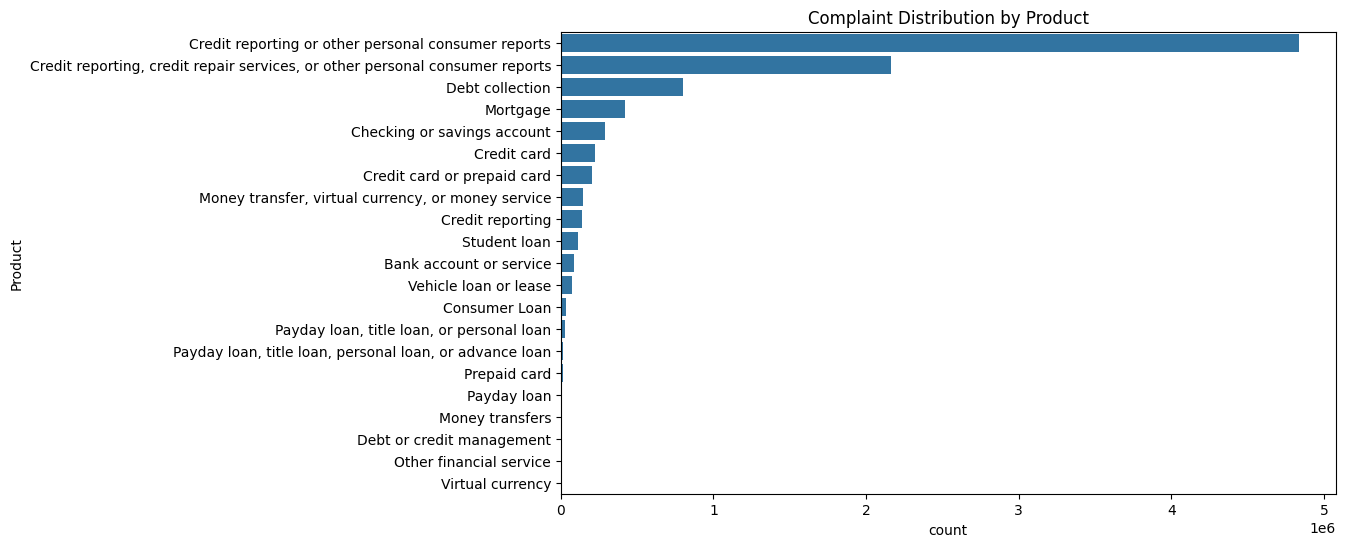

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='Product',
    data=df,
    order=df['Product']
          .value_counts()
          .index
)

plt.title('Complaint Distribution by Product')

plt.show()

In [15]:
target_products = [
    "Credit card",
    "Personal loan",
    "Savings account",
    "Money transfer"
]

filtered_df = df[
    df["Product"].isin(target_products)
]

print(filtered_df.shape)

(226686, 18)


In [16]:
filtered_df = filtered_df[
    filtered_df["Consumer complaint narrative"].notna()
]

print(filtered_df.shape)

(80667, 18)


In [19]:
df['word_count'] = (
    df['Consumer complaint narrative']
    .fillna('')
    .str.count(r'\S+')
)

In [20]:
df['word_count'].describe()

count    9.609797e+06
mean     5.446667e+01
std      1.497672e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: word_count, dtype: float64

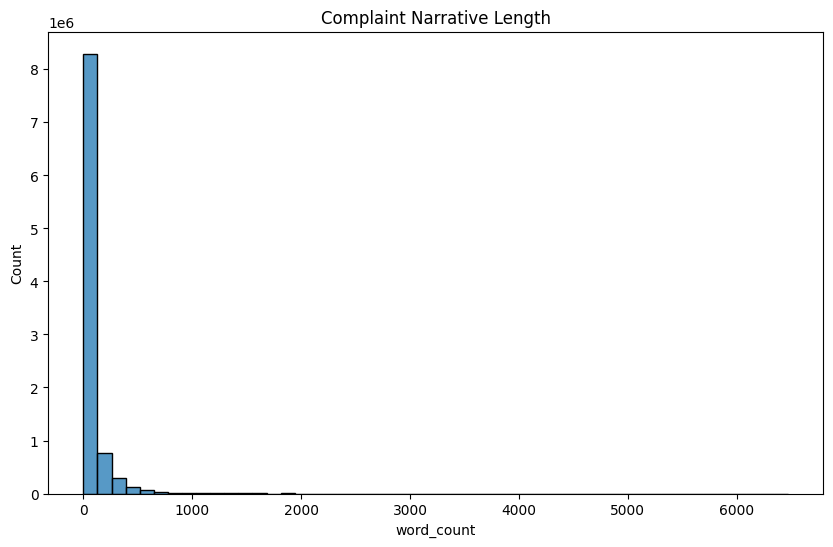

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['word_count'],
    bins=50
)

plt.title("Complaint Narrative Length")

plt.show()

In [22]:
df.nlargest(
    10,
    'word_count'
)[['word_count']]

,word_count
2946941,6469
6496462,6314
1695564,6312
527180,6291
5711279,6095
5880715,6024
5881163,6024
9442236,6024
5655392,6014
6292500,5988


Product Filtering

In [26]:
products = [
    "Credit card",
    "Personal loan",
    "Savings account",
    "Money transfer"
]

In [27]:
filtered_df = df[
    df['Product'].isin(products)
]

In [28]:
filtered_df.shape

(226686, 19)

Remove Empty Narratives

In [29]:
filtered_df = filtered_df[
    filtered_df['Consumer complaint narrative']
    .notna()
]

In [30]:
filtered_df.shape

(80667, 19)

Text Cleaning

In [31]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(
        r'i am writing to file a complaint',
        '',
        text
    )

    text = re.sub(
        r'[^a-zA-Z0-9\s]',
        ' ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip()

In [32]:
filtered_df['cleaned_text'] = (
    filtered_df[
        'Consumer complaint narrative'
    ].apply(clean_text)
)

In [33]:
filtered_df[
'Consumer complaint narrative'
].iloc[0]

'A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unauthorized and not me. XXXX XXXX confirmed this was fraudulent and immediately closed the card. However, they have failed to remove this from the three credit agencies and this fraud is now impacting my credit score based on a hard credit pull done by XXXX XXXX that was done by a fraudster.'

In [34]:
filtered_df[
'cleaned_text'
].iloc[0]

'a xxxx xxxx card was opened under my name by a fraudster i received a notice from xxxx that an account was just opened under my name i reached out to xxxx xxxx to state that this activity was unauthorized and not me xxxx xxxx confirmed this was fraudulent and immediately closed the card however they have failed to remove this from the three credit agencies and this fraud is now impacting my credit score based on a hard credit pull done by xxxx xxxx that was done by a fraudster'

In [35]:
filtered_df.to_csv(
    "../data/processed/filtered_complaints.csv",
    index=False
)

In [36]:
pd.read_csv(
    "../data/processed/filtered_complaints.csv"
).head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,word_count,cleaned_text
0,2025-06-13,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,Servicemember,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121,91,a xxxx xxxx card was opened under my name by a...
1,2025-06-12,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,NaN,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085,156,dear cfpb i have a secured credit card with ci...
2,2025-06-12,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,NaN,Consent provided,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217,233,i have a citi rewards cards the credit balance...
3,2025-06-09,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411,454,b i am writing to dispute the following charge...
4,2025-06-09,Credit card,General-purpose credit card or charge card,Problem when making payments,Problem during payment process,"Although the account had been deemed closed, I...",Company believes it acted appropriately as aut...,Atlanticus Services Corporation,NY,11212,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13965746,170,although the account had been deemed closed i ...


Summary

1. The CFPB complaint dataset contains over 9.6 million complaint records spanning multiple financial products and institutions. Initial data quality assessment revealed substantial missingness in several fields, particularly the consumer complaint narrative column. Approximately 6.6 million complaints lacked narrative text, leaving only a subset of records suitable for semantic search and retrieval. Because customer narratives form the primary knowledge source for a Retrieval-Augmented Generation (RAG) system, records without textual descriptions were excluded from subsequent analysis and indexing.

2. Complaint volumes were not evenly distributed across products. Certain financial services generated substantially more complaints than others, indicating higher levels of customer dissatisfaction or greater customer usage. To align with the business requirements of CrediTrust Financial, the analysis focused exclusively on Credit Cards, Personal Loans, Savings Accounts, and Money Transfers. Restricting the dataset to these categories ensured that the resulting chatbot would provide relevant insights for the company's core financial products.

3. Analysis of narrative lengths showed significant variability in the amount of detail provided by customers. While some complaints consisted of only a few words, others contained extensive descriptions spanning hundreds of words. This variation highlights the importance of text chunking during embedding generation, as lengthy narratives may exceed the optimal context size for semantic retrieval models. To improve data consistency and retrieval quality, narratives were preprocessed through lowercasing, removal of special characters, elimination of boilerplate phrases, and whitespace normalization. These preprocessing steps produced a cleaner corpus suitable for embedding generation and vector database indexing.